(1925, 6969, 3)


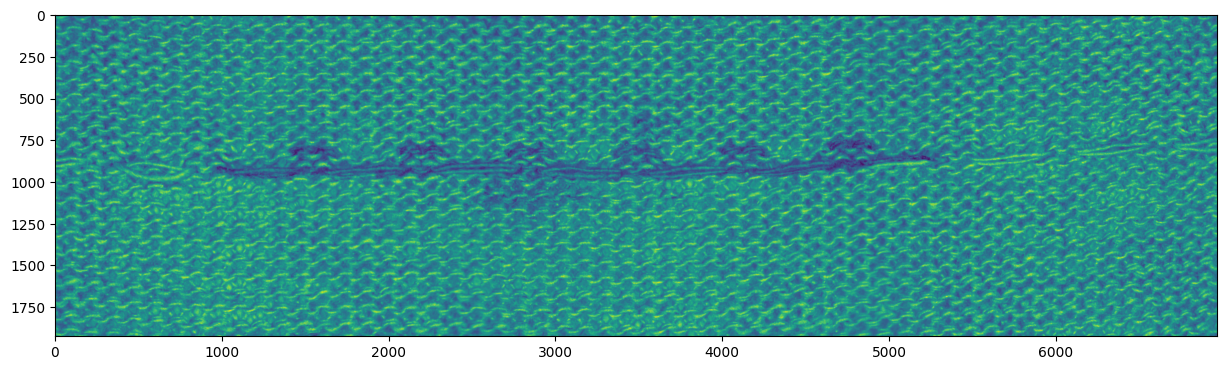

In [2]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

def show(img):
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.imshow(img)
    plt.show()
    
img = cv2.imread('data/podl3_rub/podl3_dra8.jp2')
print(img.shape)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
show(gray)

118.0


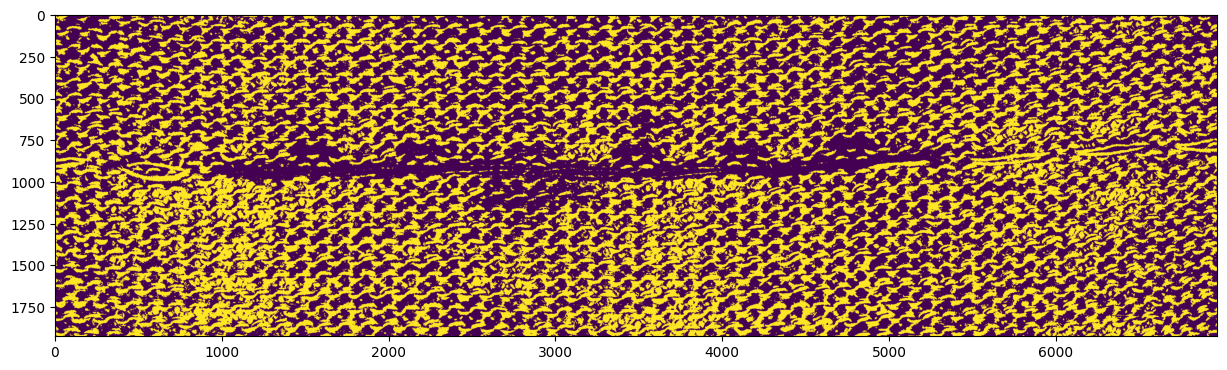

In [3]:
threshod, seg = cv2.threshold(gray,0,255, cv2.THRESH_OTSU)
print(threshod)
show(seg)

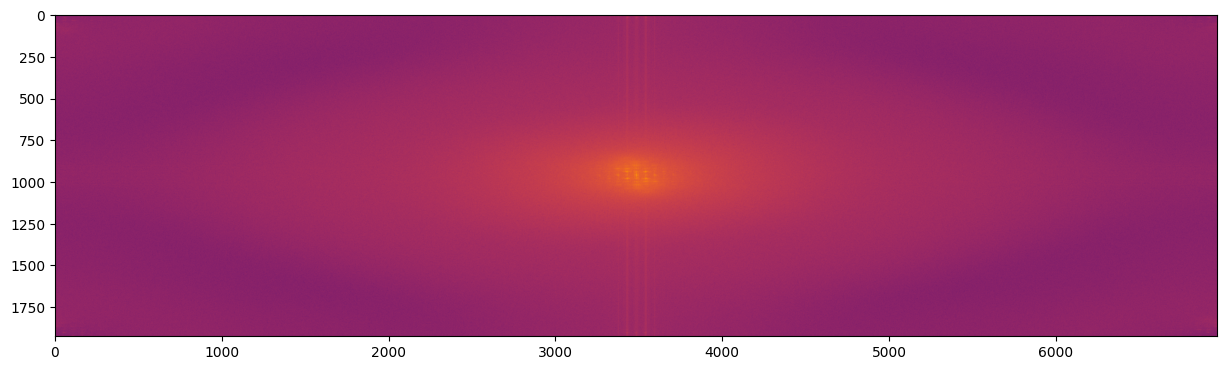

In [60]:
# fft
import matplotlib.pyplot as plt

ft = np.fft.fft2(gray)
ftshift = np.fft.fftshift(ft)
spectre = 20*np.log(np.abs(ftshift))

# show(spectre)
plt.figure(figsize=(15,30))
plt.imshow(spectre, cmap='inferno')

'input img'

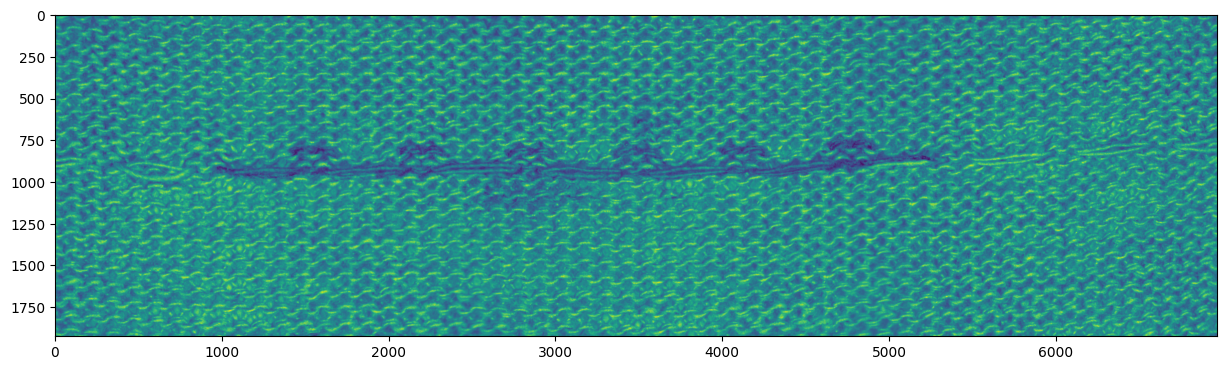

'low-pass filtered img'

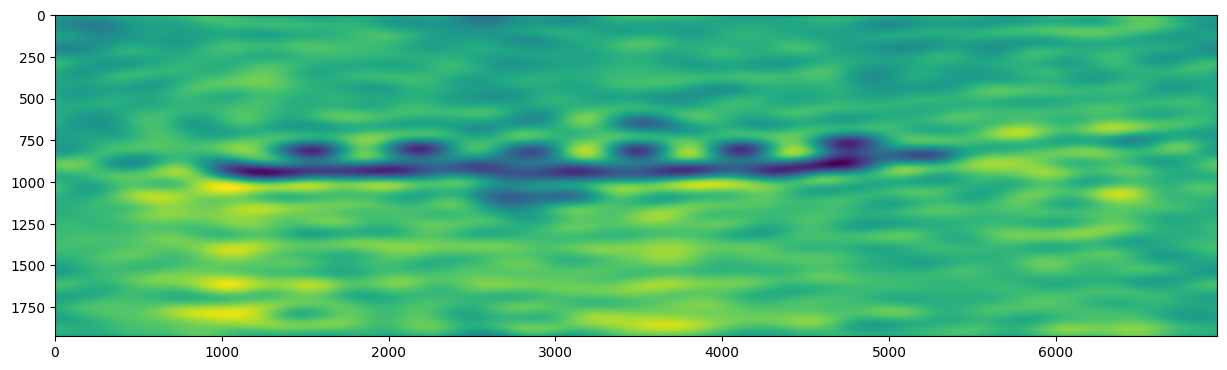

'low-pass fft mask'

/var/folders/28/k9ff45kn2kn92nh5v2qynkkr0000gn/T/ipykernel_30671/1490778192.py:25: RuntimeWarning: divide by zero encountered in log
  show(np.log(np.abs(ftshift_mask)))


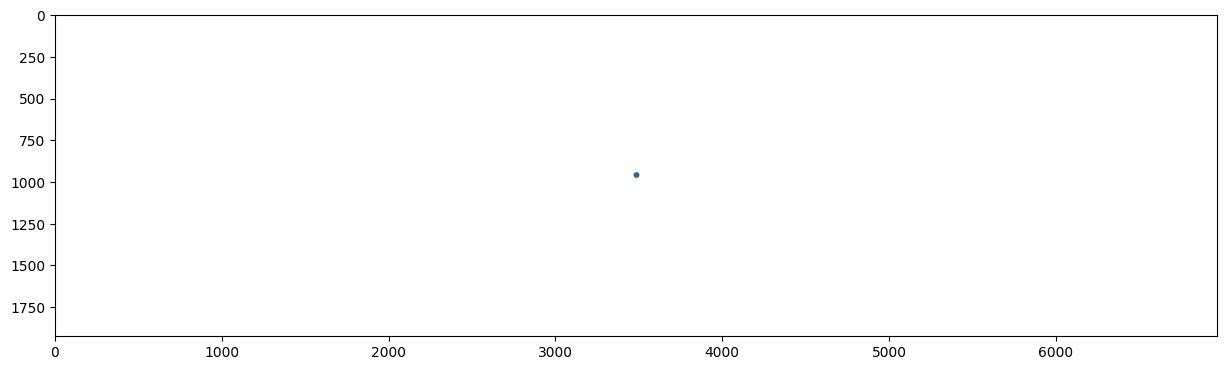

In [6]:
# LO PASS FILTERING 
RADIUS = 17

img = gray

ft = np.fft.fft2(img)
ftshift = np.fft.fftshift(ft)
spectre = 20*np.log(np.abs(ftshift))

x, y = np.indices(img.shape)
center = (img.shape[0]//2, img.shape[1]//2)
mask = (x - center[0])**2 + (y - center[1])**2 < RADIUS**2

ftshift_mask = ftshift*(mask)
ftishift_back = np.fft.ifftshift(ftshift_mask)
img_back = np.fft.ifft2(ftishift_back)
img_back = np.abs(img_back)

# Visualization
display("input img")
show(img)
display("low-pass filtered img")
show(img_back)
display("low-pass fft mask")
show(np.log(np.abs(ftshift_mask)))

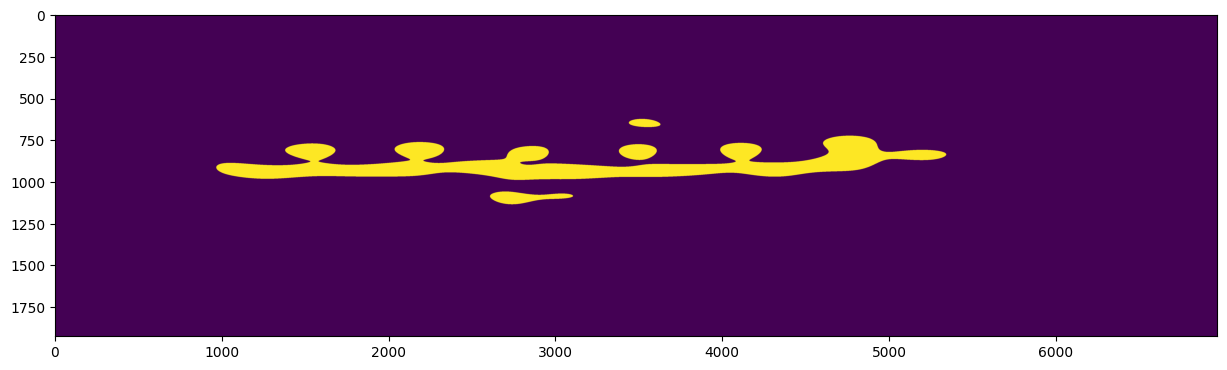

In [49]:
# fft^(-1) img threshold -> binary
threshold, seg = cv2.threshold(img_back, 100, 255, cv2.THRESH_BINARY_INV)

show(seg.astype(bool))

In [11]:
seg_binary = seg > threshold
area = np.sum(seg_binary)

area_relative = area / (seg.shape[0]*seg.shape[1])
print(area_relative)
print(f"{area_relative*100:.2f}%")

0.037533343396451445
3.75%


In [23]:
# lx
lx = np.sum(seg_binary, axis=0, dtype=bool).sum()
ly = np.sum(seg_binary, axis=1, dtype=bool).sum()
print(lx, ly)

4375 391
